<a href="https://colab.research.google.com/github/Nourana32/TREESS/blob/main/REMOTE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 green area : 84.40%
 number of trees: 9


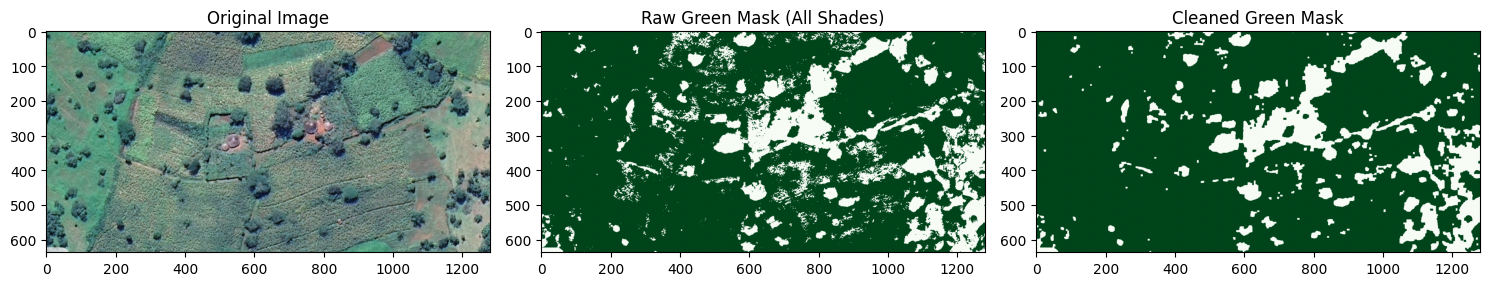

In [2]:
# Install necessary libraries
!pip install opencv-python-headless scikit-image

# Import libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import label, regionprops
from PIL import Image

# Load the image
image_path = "/content/treess.jpeg"
image = Image.open(image_path)
image_np = np.array(image)

# Convert image to HSV color space
hsv = cv2.cvtColor(image_np, cv2.COLOR_RGB2HSV)

# Combine multiple green ranges (to capture various shades)
# Range 1: light green
lower_green1 = np.array([25, 30, 30])
upper_green1 = np.array([40, 255, 255])

# Range 2: mid green
lower_green2 = np.array([40, 30, 30])
upper_green2 = np.array([70, 255, 255])

# Range 3: dark green
lower_green3 = np.array([70, 30, 30])
upper_green3 = np.array([95, 255, 255])

# Create masks for each range
mask1 = cv2.inRange(hsv, lower_green1, upper_green1)
mask2 = cv2.inRange(hsv, lower_green2, upper_green2)
mask3 = cv2.inRange(hsv, lower_green3, upper_green3)

# Combine all green masks
green_mask = cv2.bitwise_or(mask1, mask2)
green_mask = cv2.bitwise_or(green_mask, mask3)

# Optional: Clean mask (morphological operations)
kernel = np.ones((5, 5), np.uint8)
green_mask_cleaned = cv2.morphologyEx(green_mask, cv2.MORPH_CLOSE, kernel)
green_mask_cleaned = cv2.morphologyEx(green_mask_cleaned, cv2.MORPH_OPEN, kernel)

# Calculate green area percentage
green_area_pixels = np.sum(green_mask_cleaned > 0)
total_pixels = image_np.shape[0] * image_np.shape[1]
green_area_percent = (green_area_pixels / total_pixels) * 100

print(f" green area : {green_area_percent:.2f}%")

# Count connected components (tree-like regions)
labeled_mask = label(green_mask_cleaned)
regions = regionprops(labeled_mask)

# Filter regions by area to remove noise
min_tree_area = 100  # pixels
tree_count = sum(1 for region in regions if region.area >= min_tree_area)

print(f" number of trees: {tree_count}")

# Visualization
plt.figure(figsize=(15, 6))
plt.subplot(1, 3, 1)
plt.imshow(image_np)
plt.title("Original Image")

plt.subplot(1, 3, 2)
plt.imshow(green_mask, cmap='Greens')
plt.title("Raw Green Mask (All Shades)")

plt.subplot(1, 3, 3)
plt.imshow(green_mask_cleaned, cmap='Greens')
plt.title("Cleaned Green Mask")

plt.tight_layout()
plt.show()